# Training with MNIST

In this notebook we will make a simple CNN and train fashion MNIST with it. Fashion MNIST is like number MNIST, instead of numbers it has got images of wearables. The classes in Fashion MNIST are

- 0 T-shirt/top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandal
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boot

In [1]:
#This segment verifies the setup
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"



# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

IS_COLAB=0
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "cnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    
def plot_image(image):
    plt.imshow(image, cmap="gray", interpolation="nearest")
    plt.axis("off")

def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")

No GPU was detected. CNNs can be very slow without a GPU.


We will do the following in this section
- Load mnist data from Keras with train_full and test sets
- Create train set and valid set
- Normalise the input data
- Add channel dimension to input

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape of full train and test sets (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)
item0 9
Shape of train and valid sets (25000, 28, 28) (25000,) (5000, 28, 28) (5000,)
Shape of features (25000, 28, 28, 1) (5000, 28, 28, 1) (10000, 28, 28, 1)


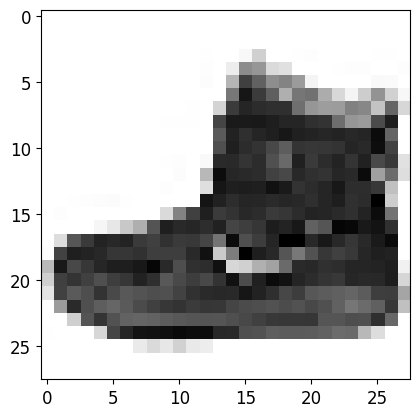

In [ ]:

print ("Shape of full train and test sets", X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape)
X_train, X_valid = X_train_full[:-35000], X_train_full[-5000:] #For training and validation sets, we split the full training set into two parts, one for training and the other for validation. We take the last 5000 samples for validation and the rest for training.
y_train, y_valid = y_train_full[:-35000], y_train_full[-5000:]

plt.imshow(X_train_full[0], cmap="Greys")
print ("item0", y_train_full[0])
print ("Shape of train and valid sets", X_train.shape, y_train.shape, X_valid.shape, y_valid.shape)

#Normalise the features set with mean and standard deviations
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

#Add an extra dimension for channels and compatibility to tools
X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print ("Shape of features", X_train.shape, X_valid.shape, X_test.shape)

- Image is 28x28 and has a single channel
- MaxPooling of 2 reduces spacial dimension by 2 keeping memory requirements in control
- Increase the number of filters (doubling)as we go deeper to create combine lower level feature to higher level features
- We flatten the data and feed to the dense layers in the end. Makes it into a single dimensional array that can be input to dense layers
- There is 50% normalisation to reduce overfitting
- And finally a 10 output dense layer with softmax to bring it down to 10 


# CNN Model Code Explanation (Beginner Friendly)

We are building a **Convolutional Neural Network (CNN)** using **Keras** to classify images of size **28 × 28 × 1** (likely grayscale images such as MNIST digits).

---

# 1. Importing `partial`

```python
from functools import partial
```

### What this does
`partial` lets us **pre-configure a function with default parameters** so we don't need to repeatedly write the same arguments.

### Why we need it
In CNNs we usually repeat many convolution layers with the same settings like:

- `kernel_size = 3`
- `activation = relu`
- `padding = SAME`

Instead of writing these every time, we create a **custom shortcut function**.

---

# 2. Creating a Default Convolution Layer

```python
DefaultConv2D = partial(
    keras.layers.Conv2D,
    kernel_size=3,
    activation='relu',
    padding="SAME"
)
```

### What this means
We are creating a **predefined version of Conv2D**.

Now whenever we call `DefaultConv2D`, it will automatically include:

- `kernel_size = 3`
- `activation = relu`
- `padding = SAME`

So instead of writing

```python
keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding="SAME")
```

we can simply write

```python
DefaultConv2D(filters=128)
```

### Why this is useful
1. Cleaner code  
2. Less repetition  
3. Easier to maintain

---

# 3. Creating the Model

```python
model = keras.models.Sequential([
```

### What Sequential means

`Sequential` means the network is built **layer by layer in order**.

The output of one layer becomes the input to the next.

Example flow:

Image → Conv → Pool → Conv → Pool → Dense → Output

---

# 4. First Convolution Layer

```python
DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1])
```

### What this layer does
This layer extracts **basic features from the image**.

### Parameters

#### filters = 64
Means **64 different filters** scan the image.

Each filter detects a different pattern like:

- edges
- curves
- textures

Result → **64 feature maps**

#### kernel_size = 7

This is the **size of the filter**.

7 × 7 filter

Why larger filter first?

Early layers need **bigger receptive field** to capture basic patterns.

#### input_shape = [28, 28, 1]

This tells the network the shape of the input image.

28 = height  
28 = width  
1 = channels  

Channels = 1 because image is **grayscale**.

---

# 5. First Pooling Layer

```python
keras.layers.MaxPooling2D(pool_size=2)
```

### What pooling does

Pooling **reduces image size** while keeping important information.

Example:

Before pooling: 28 × 28  
After pooling: 14 × 14  

### How Max Pooling works

Example:

2×2 region

4 8  
6 2  

Max value = 8

Only the **largest value** is kept.

### Why pooling is used

1. Reduces computation  
2. Makes model faster  
3. Keeps strongest features  
4. Provides **translation invariance**

---

# 6. Second Convolution Block

```python
DefaultConv2D(filters=128)
DefaultConv2D(filters=128)
```

### Why two convolution layers?

Stacking layers allows the network to learn **more complex features**.

Example progression:

Layer 1 → edges  
Layer 2 → shapes  
Layer 3 → parts of objects  

### Why filters increased to 128?

Important CNN design principle:

As spatial size ↓  
Feature depth ↑  

Because pooling reduces image size, we compensate by learning **more feature types**.

---

# 7. Second Pooling Layer

```python
keras.layers.MaxPooling2D(pool_size=2)
```

Again reduces spatial dimension.

Example:

14×14 → 7×7

---

# 8. Third Convolution Block

```python
DefaultConv2D(filters=256)
DefaultConv2D(filters=256)
```

Now filters increased again.

### Why 256 filters?

Because deeper layers detect **very complex patterns**.

Examples:

Early layer detects:  
edges  

Middle layer detects:  
corners  
circles  

Deep layer detects:  
digits  
object parts  

More filters = more pattern detectors.

---

# 9. Third Pooling Layer

```python
keras.layers.MaxPooling2D(pool_size=2)
```

Reduces size again.

Example:

7×7 → 3×3

Now we have:

many feature maps  
small spatial size  

---

# 10. Flatten Layer

```python
keras.layers.Flatten()
```

CNN layers output **3D data**:

height × width × channels

Example:

3 × 3 × 256

Dense layers require **1D input**.

Flatten converts:

3 × 3 × 256

into

2304 values

---

# 11. First Dense Layer

```python
keras.layers.Dense(units=128, activation='relu')
```

Dense layers are **fully connected layers**.

Each neuron connects to all inputs.

### Purpose

They combine extracted features to perform **final reasoning**.

Example:

CNN extracts:

edges  
curves  
patterns  

Dense layer decides:

This looks like digit 7

---

# 12. Dropout Layer

```python
keras.layers.Dropout(0.5)
```

### What dropout does

Randomly disables **50% of neurons during training**.

Example:

Neuron A → disabled  
Neuron B → active  
Neuron C → disabled  

### Why this is important

Prevents **overfitting**.

Without dropout:  
Model memorizes training data.

With dropout:  
Model learns **general patterns**.

---

# 13. Second Dense Layer

```python
keras.layers.Dense(units=64, activation='relu')
```

Another fully connected layer to refine predictions.

This layer helps the network combine features further.

---

# 14. Another Dropout Layer

```python
keras.layers.Dropout(0.5)
```

Again prevents overfitting.

Deep networks easily memorize data.

Dropout improves **generalization**.

---

# 15. Output Layer

```python
keras.layers.Dense(units=10, activation='softmax')
```

### Why 10 units?

Because there are **10 classes**:

0 1 2 3 4 5 6 7 8 9

### What Softmax does

Softmax converts outputs into **probabilities**.

Example output:

[0.01, 0.02, 0.03, 0.80, 0.04, ...]

Meaning:

80% probability that image is digit 3

---

# Why Filters Increase in CNNs

Typical CNN pattern:

Conv(64)  
Conv(128)  
Conv(256)  
Conv(512)

### Reason

Early layers detect **simple patterns**.

edges  
lines  
gradients  

Later layers detect **complex patterns**.

shapes  
objects  
digits  

As spatial resolution decreases (due to pooling), we increase filters to **capture richer features**.

Rule of thumb:

Width ↓  
Depth ↑

---

# Why Dense Layers Are Needed

CNN layers only **extract features**.

Example extracted features:

edge  
curve  
loop  
corner  

Dense layers act like a **decision maker**.

They combine features and determine:

Which class does this belong to?

---

# What Optimizers Do

An optimizer updates the **weights of the network** during training.

Goal:

Minimize loss (error)

Example optimizers:

SGD  
Adam  
RMSprop

### Example

If prediction is wrong:

Predicted = 3  
Actual = 7

Optimizer adjusts weights so next prediction becomes closer to **7**.

### Most common optimizer

Adam

Why?

Fast  
Stable  
Works well for most problems

Example:

```python
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
```

---

# Full Architecture Summary

Input (28×28×1)

Conv 64  
Pool  

Conv 128  
Conv 128  
Pool  

Conv 256  
Conv 256  
Pool  

Flatten  

Dense 128  
Dropout  

Dense 64  
Dropout  

Output 10 (Softmax)

In [3]:
from functools import partial

#Create a function with which we can more easily add convolution layers
DefaultConv2D = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")

model = keras.models.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]), #Based on input size
    keras.layers.MaxPooling2D(pool_size=2), #Same maxpooling applied regularly
    DefaultConv2D(filters=128),  
    DefaultConv2D(filters=128),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/Users/akash/cloudXlabs/cloudxlabs_mylearnings_projects/.venv310/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=2, validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)

Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 85ms/step - accuracy: 0.6803 - loss: 0.9028 - val_accuracy: 0.8250 - val_loss: 0.4964
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 95ms/step - accuracy: 0.8141 - loss: 0.5419 - val_accuracy: 0.8480 - val_loss: 0.4267
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8438 - loss: 0.4401


In [5]:
print (score)

[0.44012612104415894, 0.8438000082969666]


In [12]:
X_new = X_test[10:20] # pretend we have new images
y_pred = model.predict(X_new)

In [13]:
#Print actual data from test
print (y_test[10:20])

[4 5 7 3 4 1 2 4 8 0]


In [14]:
#Print the output of the predicted set
print (np.argmax(y_pred, axis=1))

[4 5 5 3 4 1 2 4 8 0]
